## Comparing Raw Protein Expression: BMIF vs Plasma

\begin{aligned}
&\text{for each time point } t: \\
&\quad \text{for each protein } p: \\
&\quad\quad \text{calculate Spearman's ρ} \text{ at time } t \\
&\quad\quad \text{optional: plot results} \\
&\quad \text{repeat for all proteins} \\
& \text{repeat for all visits} \\
\end{aligned}

In [1]:
source("../utilities/functions/helper_functions_olink.R")

# Load necessary libraries
suppressPackageStartupMessages({
  library(ComplexHeatmap)
  require(data.table)
  require(ggplot2)
  require(dplyr)
  require(tidyr)
  require(ggpubr)
  library(reshape2)
})

In [2]:
bm <- readRDS('../../data/figure-inputs/olink/MM_BMIF_Olink_Final.rds')
plasma <- readRDS('../../data/figure-inputs/olink/MM_Plasma_Olink_Final.rds')
plasma <- plasma[cohort.cohortGuid=='FH1']

In [3]:
### Extract plasma expression data
plasma_exp <- plasma[, c("olink.assay", "olink.NPX_norm", "subject.subjectGuid", "sample.visitDetails", "sample.sampleKitGuid")]
plasma_exp$Tissue <- "Plasma"

### Extract bm expression data
bm_exp <- bm[, c("olink.assay", "olink.NPX_norm", "subject.subjectGuid", "sample.visitDetails", "SampleKitGuid")]
bm_exp$Tissue <- "Bone Marrow"
colnames(bm_exp) <- colnames(plasma_exp)

### Combine into a single matrix for correlations
combined_exp <- rbind(bm_exp, plasma_exp)
combined_exp$sample.visitDetails <- gsub("ASCT60d", "ASCT60_90d", combined_exp$sample.visitDetails)
combined_exp$sample.visitDetails <- gsub("ASCT90d", "ASCT60_90d", combined_exp$sample.visitDetails)

In [4]:
estimate_correlation <- function(timePoint, protein, Plot = F, size = 4) {
  tmp <- combined_exp[olink.assay == protein & sample.visitDetails == timePoint]
  tmp2 <- dcast(tmp, formula = subject.subjectGuid + sample.visitDetails ~ Tissue, value.var = "olink.NPX_norm", fun.aggregate = mean)
  tmp2 <- tmp2[complete.cases(tmp2), ]

  p <- ggplot(
    tmp2,
    aes(x = `Bone Marrow`, y = Plasma)
  ) +
    geom_smooth(
      formula = y ~ x,
      method = MASS::rlm,
      method.args = list((maxit <- 100)),
      color = "#8B0000"
    ) +
    geom_point(aes(color = subject.subjectGuid), size = 3, alpha = 0.7) +
    scale_color_manual(values = subject_color_map) +
    xlab("BMIF Olink") +
    ylab("Plasma Olink") +
    ggpubr::stat_cor(method = "spearman", size = size) +
    ggtitle(protein) +
    theme_linedraw(base_size = 14) +
    theme(
      legend.position = "none",
      panel.grid.major = element_blank(),
      panel.grid.minor = element_blank(),
      plot.title = element_text(face = "bold"),
      panel.border = element_rect(linewidth = 1, fill = NA)
    )

  if (Plot) {
    return(p)
  } else {
    res <- data.frame(
      assay       = protein,
      visit       = timePoint,
      Bm_Exp      = median(tmp2$`Bone Marrow`, na.rm = T),
      Plasma_Exp  = median(tmp2$Plasma, na.rm = T),
      Correlation = cor(tmp2$`Bone Marrow`, tmp2$Plasma, method = "spearman")
    )
    return(res)
  }
}

## Supp Fig1 J Visualizations

In [5]:
subject_color_map <- c(
  "FH1001" = "#1f77b4",
  "FH1002" = "#ff7f0e",
  "FH1003" = "#279e68",
  "FH1004" = "#d62728",
  "FH1005" = "#aa40fc",
  "FH1006" = "#8c564b",
  "FH1007" = "#e377c2",
  "FH1008" = "#b5bd61",
  "FH1009" = "#17becf",
  "FH1010" = "#aec7e8",
  "FH1011" = "#ffbb78",
  "FH1012" = "#98df8a",
  "FH1014" = "#ff9896",
  "FH1016" = "#c5b0d5",
  "FH1017" = "#c49c94",
  "FH1018" = "#f7b6d2",
  "FH1021" = "#dbdb8d"
)

Warning message in rlm.default(x, y, weights, method = method, wt.method = wt.method, :
“'rlm' failed to converge in 20 steps”


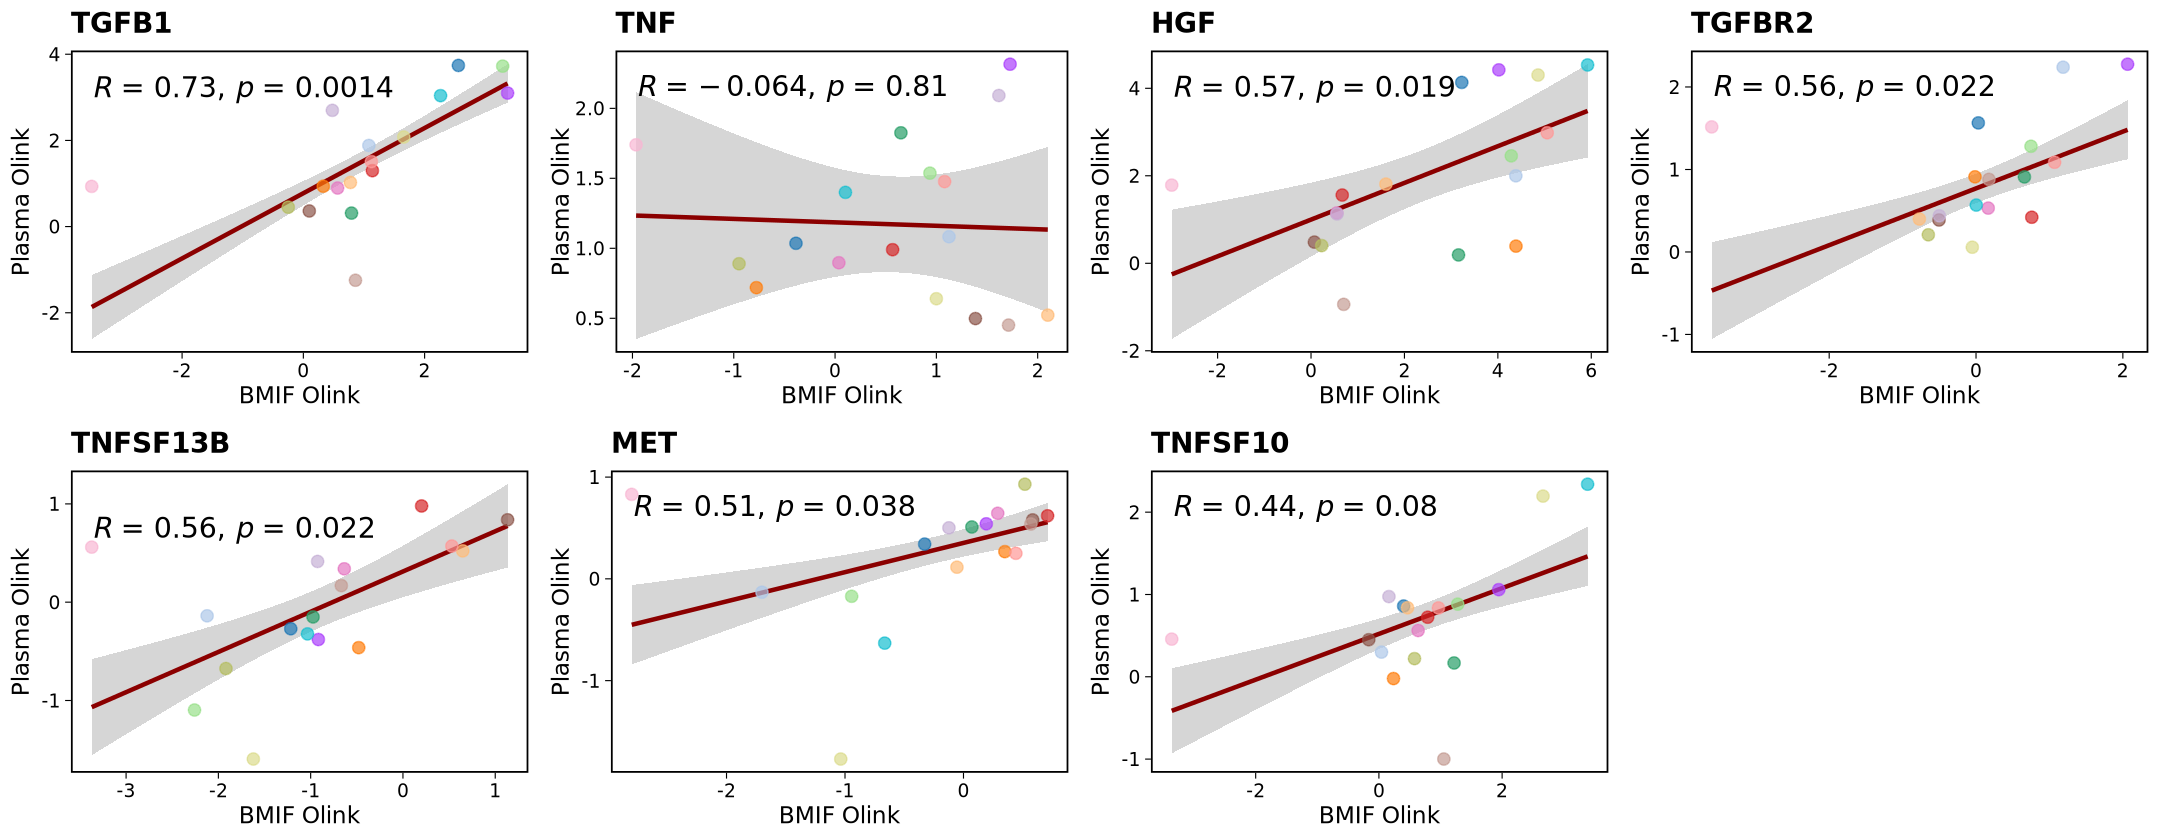

In [6]:
options(repr.plot.width = 18, repr.plot.height = 7)

plotlist <- lapply(
  c("TGFB1", "TNF", "HGF", "TGFBR2", "TNFSF13B", "MET", "TNFSF10"),
  function(x) {
    estimate_correlation(timePoint = "PreTx", protein = x, Plot = T, size = 6) +
      theme(legend.position = "none")
  }
)

p <- ggpubr::ggarrange(plotlist = plotlist, ncol = 4, nrow = 2)
p

ggsave("../../data/figure-outputs/supplementary-1/sup_1j.pdf", plot = p, width = 18, height = 7, dpi = 200, device = cairo_pdf)

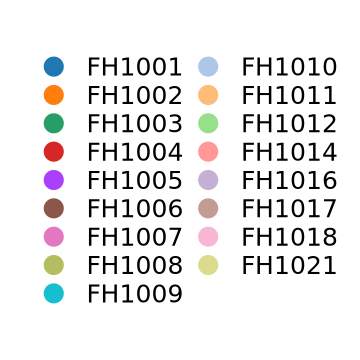

In [7]:
dummy_plot <- ggplot(
  data.frame(subject = names(subject_color_map), x = 1, y = 1),
  aes(x = x, y = y, color = subject)
) +
  geom_point(size = 5) +
  scale_color_manual(values = subject_color_map) +
  theme_void() +
  theme(
    legend.text = element_text(size = 15),
    legend.key.size = unit(0.6, "cm"),
    legend.title = element_blank()
  ) +
  guides(color = guide_legend(ncol = 2, keywidth = unit(1, "cm")))

options(repr.plot.width = 3, repr.plot.height = 3)
p2 <- get_legend(dummy_plot) %>% as_ggplot()

p2
ggsave("../../data/figure-outputs/supplementary-1/sup_1j-legend.pdf", plot = p2, width = 3, height = 3, dpi = 200, device = cairo_pdf)